Import Library

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

Read Dataset

In [47]:
df_weather = pd.read_csv('seattle-weather.csv')
df = df_weather.drop(columns=["date","weather"])

In [48]:
df_weather.describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


In [49]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


Eksplorasi Data (Visualisasi Scatter Plot)

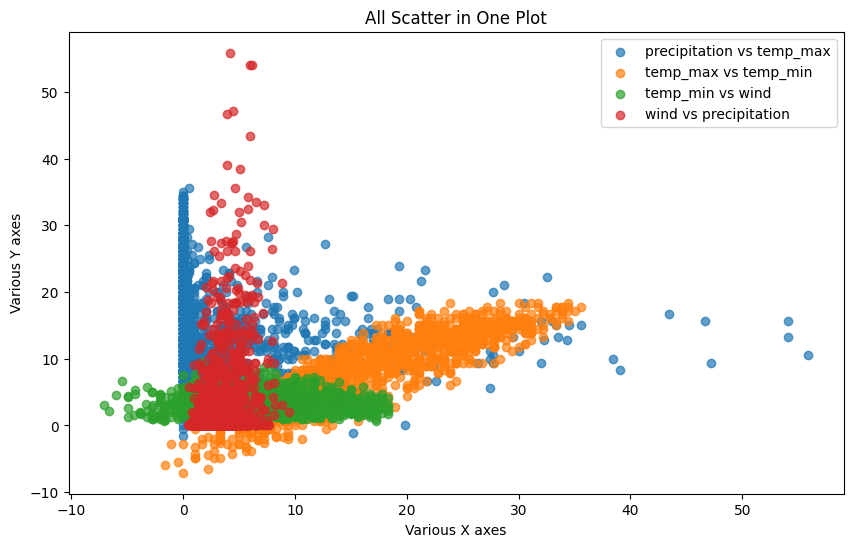

In [50]:
plt.figure(figsize=(10, 6))

plt.scatter(df_weather['precipitation'], df_weather['temp_max'], label='precipitation vs temp_max', alpha=0.7)
plt.scatter(df_weather['temp_max'], df_weather['temp_min'], label='temp_max vs temp_min', alpha=0.7)
plt.scatter(df_weather['temp_min'], df_weather['wind'], label='temp_min vs wind', alpha=0.7)
plt.scatter(df_weather['wind'], df_weather['precipitation'], label='wind vs precipitation', alpha=0.7)

plt.xlabel("Various X axes")
plt.ylabel("Various Y axes")
plt.title("All Scatter in One Plot")
plt.legend()
plt.show()

Data Training

In [51]:
x_train = df[['precipitation','temp_max', 'temp_min', 'wind']].values

Feature Scalling 

In [52]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x_train)
x_scaled

array([[0.        , 0.38709677, 0.47637795, 0.47252747],
       [0.19499106, 0.32795699, 0.38976378, 0.45054945],
       [0.01431127, 0.35752688, 0.56299213, 0.20879121],
       ...,
       [0.        , 0.23655914, 0.30314961, 0.24175824],
       [0.        , 0.19354839, 0.24015748, 0.32967033],
       [0.        , 0.19354839, 0.19685039, 0.34065934]], shape=(1461, 4))

Clustering 

In [53]:
from sklearn.cluster import KMeans

kmean = KMeans(n_clusters=5)
kmean


,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [54]:
y_cluster = kmean. fit_predict(x_scaled)
y_cluster

array([3, 3, 1, ..., 4, 4, 4], shape=(1461,), dtype=int32)

In [55]:
df['Cluster'] = y_cluster
df

,precipitation,temp_max,temp_min,wind,Cluster
0,0.0,12.8,5.0,4.7,3
1,10.9,10.6,2.8,4.5,3
2,0.8,11.7,7.2,2.3,1
3,20.3,12.2,5.6,4.7,0
4,1.3,8.9,2.8,6.1,3
...,...,...,...,...,...
1456,8.6,4.4,1.7,2.9,4
1457,1.5,5.0,1.7,1.3,4
1458,0.0,7.2,0.6,2.6,4
1459,0.0,5.6,-1.0,3.4,4


Centroid Cluster

In [56]:
kmean.cluster_centers_

array([[0.45431402, 0.3958161 , 0.59443771, 0.47182305],
       [0.02693045, 0.49269067, 0.62365046, 0.25719384],
       [0.01107145, 0.72577548, 0.82560144, 0.26816732],
       [0.07498873, 0.35276248, 0.50534537, 0.54324131],
       [0.03187097, 0.26878307, 0.35264342, 0.22072214]])

Visualisasi Data Hasil Clustering 

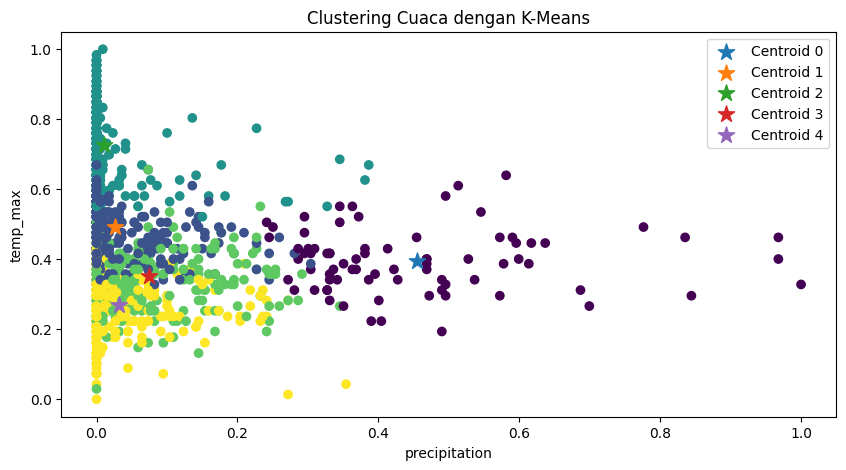

In [57]:
plt.figure(figsize=(10,5))

plt.scatter(x_scaled[:,0], x_scaled[:,1], c=kmean.labels_)
plt.scatter(kmean.cluster_centers_[0,0], kmean.cluster_centers_[0,1],
            marker='*', s=150, label='Centroid 0')
plt.scatter(kmean.cluster_centers_[1,0], kmean.cluster_centers_[1,1],
            marker='*', s=150, label='Centroid 1')
plt.scatter(kmean.cluster_centers_[2,0], kmean.cluster_centers_[2,1],
            marker='*', s=150, label='Centroid 2')
plt.scatter(kmean.cluster_centers_[3,0], kmean.cluster_centers_[3,1],
            marker='*', s=150, label='Centroid 3')
plt.scatter(kmean.cluster_centers_[4,0], kmean.cluster_centers_[4,1],
            marker='*', s=150, label='Centroid 4')
plt.xlabel("precipitation")
plt.ylabel("temp_max")
plt.title("Clustering Cuaca dengan K-Means")
plt.legend()
plt.show()


Menacri K (Jumlah Cluster) Terbaik

In [58]:
inertias = []
k_range = range(1, 10)
for k in k_range:
    km = KMeans(n_clusters=k).fit(x_scaled)
    inertias.append(km.inertia_)

In [59]:
inertias

[171.38756366715944,
 92.93592831155634,
 69.60651631695896,
 60.59650560899249,
 49.287665809630866,
 43.4810944697149,
 39.82851312263614,
 37.29166305951959,
 34.66367034299034]

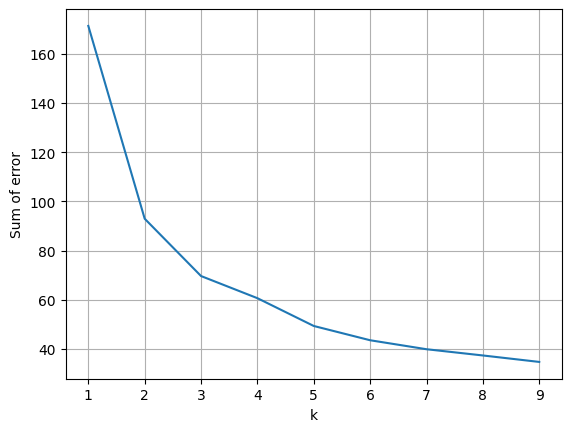

In [60]:
plt.xlabel("k")
plt.ylabel("Sum of error")
plt.plot(k_range, inertias)
plt.grid()

In [61]:
from sklearn.cluster import KMeans
import numpy as np

def find_best_k_elbow(x_scaled, max_k=10):
    inertias = []
    k_range = range(1, max_k+1)

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42).fit(x_scaled)
        inertias.append(km.inertia_)

    # Hitung perbedaan inertia (kemiringan)
    diffs = np.diff(inertias)
    # K terbaik adalah titik perubahan terbesar
    best_k = np.argmin(diffs) + 1
    return best_k, inertias

best_k, inertias = find_best_k_elbow(x_scaled)
print("K terbaik (Elbow):", best_k)

K terbaik (Elbow): 1


EVALUASI

In [62]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# model KMeans
kmean = KMeans(n_clusters=5, random_state=42)
kmean.fit(x_scaled)

# Prediksi cluster
labels = kmean.labels_

# Evaluasi
sil = silhouette_score(x_scaled, labels)
dbi = davies_bouldin_score(x_scaled, labels)
chi = calinski_harabasz_score(x_scaled, labels)

print("Silhouette Score:", sil)
print("Davies-Bouldin Index:", dbi)
print("Calinski-Harabasz:", chi)


Silhouette Score: 0.314846311635585
Davies-Bouldin Index: 1.0567879187218103
Calinski-Harabasz: 902.9254659876592


1. Silhouette → pilih yang terbesar
2. DBI → pilih yang terkecil
3. CHI → pilih yang terbesar

Silhouette Score → mengukur kesesuaian data dengan clusternya, makin besar makin bagus.
Davies-Bouldin Index → mengukur tumpang tindih antar cluster, makin kecil makin bagus.
Calinski–Harabasz Index → menilai kekompakan dan pemisahan cluster, makin besar makin bagus.

Kesimpulan data cluster ini 
1. Silhouette Score = 0.3365
Interpretasi: 0.33 itu kategori “cukup / lumayan”
Artinya cluster terbentuk, tapi pemisahan antar cluster tidak terlalu kuat
Cluster OK, tapi tidak sangat jelas pemisahannya.

2. Davies-Bouldin Index = 0.938
Interpretasi: DBI < 1 artinya bagus
Semakin kecil mendekati 0 → cluster makin bagus
Cluster relatif baik dan tidak terlalu tumpang tindih.

3. Calinski-Harabasz Index = 1335.12
Interpretasi:Nilai CHI besar → cluster terjaga rapi dan cukup terpisah
Angka 1335 itu termasuk tinggi

Membuat Dataset Baru Dengan Label Cluster 

In [63]:
# Kembalikan centroid ke skala asli agar mudah dibaca
centers_original = scaler.inverse_transform(kmean.cluster_centers_)
centers_df = pd.DataFrame(
    centers_original,
    columns=['precipitation', 'temp_max', 'temp_min', 'wind']
)
centers_df.index.name = 'cluster'
print(centers_df.round(2))

         precipitation  temp_max  temp_min  wind
cluster                                         
0                 0.46     26.12     14.12  2.82
1                 4.00     11.55      5.76  5.27
2                 1.61     17.67      9.54  2.80
3                25.35     12.90      7.74  4.73
4                 1.73      8.79      2.17  2.37


In [64]:
def assign_label_from_centroid(row):
    p = row['precipitation']
    t = row['temp_max']
    w = row['wind']

    if p > 15:                   
        return "Hujan"
    elif t >= 24 and p < 1:      
        return "Panas"
    elif t < 10:                  
        return "Mendung"
    elif w > 4.5 and t < 15:      
        return "Berangin"
    else:                         
        return "Cerah"

cluster_label_map = centers_df.apply(assign_label_from_centroid, axis=1).to_dict()
print("Mapping:", cluster_label_map)

df['Cluster_Label'] = df['Cluster'].map(cluster_label_map)
df[['precipitation','temp_max','temp_min','wind','Cluster','Cluster_Label']].head(50)

Mapping: {0: 'Panas', 1: 'Berangin', 2: 'Cerah', 3: 'Hujan', 4: 'Mendung'}


,precipitation,temp_max,temp_min,wind,Cluster,Cluster_Label
0,0.0,12.8,5.0,4.7,3,Hujan
1,10.9,10.6,2.8,4.5,3,Hujan
2,0.8,11.7,7.2,2.3,1,Berangin
3,20.3,12.2,5.6,4.7,0,Panas
4,1.3,8.9,2.8,6.1,3,Hujan
5,2.5,4.4,2.2,2.2,4,Mendung
6,0.0,7.2,2.8,2.3,4,Mendung
7,0.0,10.0,2.8,2.0,4,Mendung
8,4.3,9.4,5.0,3.4,4,Mendung
9,1.0,6.1,0.6,3.4,4,Mendung


In [65]:
data_baru = np.array([
    [0.5, 33, 22, 2],    
    [1.5, 18, 4, 3],    
    [4.0, 12,  6, 5],   
    [26,  13,  8, 5],    
    [8,  2,  3, 2],    
])

data_baru_scaled = scaler.transform(data_baru)
cluster_hasil = kmean.predict(data_baru_scaled)

hasil_df = pd.DataFrame(data_baru, columns=['precipitation', 'temp_max', 'temp_min', 'wind'])
hasil_df['Cluster'] = cluster_hasil
hasil_df['Cuaca'] = hasil_df['Cluster'].map(cluster_label_map)

print(hasil_df)

   precipitation  temp_max  temp_min  wind  Cluster     Cuaca
0            0.5      33.0      22.0   2.0        0     Panas
1            1.5      18.0       4.0   3.0        2     Cerah
2            4.0      12.0       6.0   5.0        1  Berangin
3           26.0      13.0       8.0   5.0        3     Hujan
4            8.0       2.0       3.0   2.0        4   Mendung


In [66]:
import joblib
joblib.dump(kmean, "kmeans.joblib")
print("Model berhasil disimpan!")

Model berhasil disimpan!
